# 🤖 Agentic RAG for Product Support - Tesla Vehicle Manual

**Author:** *José Ignacio Orlando, PhD*

In this example, we're going to learn how to build a Retrieval-Augmented Generation (RAG) application using LangGraph. The application allows users to ask questions about the Tesla vehicle user manual, leveraging a vector database for efficient semantic search and OpenAI's embedding model to process and retrieve relevant information.

Our RAG application is divided into two main parts:

1. **Data Ingestion**: Extract text from the PDF manual, chunk it into manageable segments, generate embeddings using OpenAI, and store them in a vector database.
2. **Agent Application**: Build a LangGraph agent that retrieves relevant information from the vector database and uses an LLM to generate accurate, context-based answers to user questions.

This example demonstrates how to combine document processing, vector search, and LLM capabilities to create an intelligent question-answering system that can accurately respond to queries about technical documentation.


# Part 1: Data Ingestion

In this section, we will process the Tesla vehicle manual PDF and create a searchable vector database. This involves extracting text, splitting it into chunks, generating embeddings, and storing everything in a vector database for efficient retrieval.


## Step 1 - Environment Setup

Before we can start processing the manual, we need to set up our environment properly. This involves:

1. **Loading environment variables**: We use `python-dotenv` to securely load our OpenAI API key from a `.env` file
2. **API key validation**: We ensure the required API key is present before proceeding
3. **Importing dependencies**: We import all necessary libraries for PDF processing, text splitting, embeddings, and vector database operations

The `load_dotenv()` function reads the `.env` file in your project directory, where you should store your OpenAI API key as `OPENAI_API_KEY=your_key_here`. This is a security best practice that prevents accidentally committing API keys to version control.

**Important**: Always remember to **not include .env files in your repository**. They should be part of your `.gitignore` file to prevent leaking your API keys online.


In [10]:
# Import environment variable management
from os import getenv  # Function to read environment variables
from dotenv import load_dotenv  # Function to load variables from .env file

# Import libraries for PDF processing
import pdfplumber  # Library for extracting text from PDF files

# Import LangChain components for text processing and embeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter  # Text chunking utility
from langchain_openai import OpenAIEmbeddings  # OpenAI embedding model interface

# Import FAISS for vector database operations
import faiss  # Facebook AI Similarity Search - lightweight vector database
import numpy as np  # Numerical operations for vectors
import pickle  # Serialization for saving metadata

# Load environment variables from .env file
load_dotenv()

# Assert that the OpenAI API key is set, otherwise raise an error
assert getenv("OPENAI_API_KEY") is not None, "Please set OPENAI_API_KEY in .env or environment."

# Configuration constants
PDF_PATH = "./support-files/Owners_Manual.pdf"  # Path to the Tesla manual PDF
VECTOR_DB_PATH = "./vector_store.faiss"  # Path where we'll save the FAISS index
METADATA_PATH = "./vector_store_metadata.pkl"  # Path where we'll save chunk metadata
EMBEDDING_MODEL = getenv("OPENAI_EMBEDDINGS_MODEL", "text-embedding-3-small") # Retrieve the embedding model from the environment variables
OPENAI_MODEL = getenv("OPENAI_MODEL", "gpt-5") # Retrieve the LLM model from the environment variables


## Step 2 - Extract Text from PDF Manual

Our first task is to extract all text content from the Tesla vehicle manual PDF. This step is critical because the quality of our text extraction directly impacts the effectiveness of our RAG system.

The `extract_text_from_pdf` function:
- Opens the PDF file using `pdfplumber`
- Extracts text from each page sequentially
- Combines all page texts into a single string
- Preserves some structure with newlines between pages

**Note**: This implementation works with text-based PDFs. For scanned PDFs, you would need to add OCR (Optical Character Recognition) upstream to convert images to text first.


In [2]:
import logging
logging.getLogger("pdfminer").setLevel(logging.ERROR) # this patch prevents pdfminer from printing warnings

# Import tqdm for progress bar
from tqdm import tqdm

# Function to extract all text from a PDF file
def extract_text_from_pdf(pdf_path: str) -> str:
    """
    Extract text content from a PDF file.
    
    Args:
        pdf_path: Path to the PDF file
        
    Returns:
        Combined text from all pages of the PDF
    """
    text_chunks = []  # List to store text from each page
    
    # Open the PDF file and extract text from all pages
    with pdfplumber.open(pdf_path) as pdf:
        # Create progress bar with total number of pages
        for page in tqdm(pdf.pages, desc="Extracting text", unit="page"):
            # Extract text from current page
            text = page.extract_text() or ""  # Use empty string if extraction returns None
            text_chunks.append(text)  # Add page text to our list
    
    # Join all page texts with newlines and strip trailing whitespace
    full_text = "\n".join(text_chunks).strip()
    
    print(f"\nTotal text length: {len(full_text)} characters")
    return full_text

# Extract text from the Tesla manual
manual_text = extract_text_from_pdf(PDF_PATH)


Extracting text: 100%|██████████| 312/312 [00:19<00:00, 15.90page/s]


Total text length: 878991 characters


## Step 3 - Chunk the Text into Manageable Segments

Now we need to split the extracted text into smaller, manageable chunks. This is important because:

1. **Embedding model limits**: Most embedding models have token limits (typically 512-8192 tokens (384-6144 words, [each token is approximately 3/4 of a word](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them?utm_source=chatgpt.com))
2. **Retrieval precision**: Smaller chunks allow for more precise retrieval of relevant information
3. **Context management**: LLMs work better with focused, relevant context rather than extremely long documents

We use `RecursiveCharacterTextSplitter` from LangChain, which intelligently splits text by:
- First trying to split on paragraph breaks
- Then trying sentence breaks
- Finally falling back to character breaks if needed

The `chunk_overlap` parameter ensures that adjacent chunks share some context, which helps maintain continuity when retrieving information that spans chunk boundaries.


In [3]:
# Initialize the text splitter with optimal parameters for technical documentation
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # Target size of each chunk in characters
    chunk_overlap=200,  # Number of characters to overlap between chunks (helps maintain context)
    length_function=len,  # Function to measure text length (using Python's len)
    separators=["\n\n", "\n", ". ", " ", ""]  # Splitting priority: paragraphs > lines > sentences > words > characters
)

# Split the manual text into chunks
text_chunks = text_splitter.split_text(manual_text)

# Display chunking statistics
print(f"Total number of chunks created: {len(text_chunks)}")
print(f"Average chunk length: {sum(len(chunk) for chunk in text_chunks) / len(text_chunks):.0f} characters")
print(f"\nFirst chunk (preview):")
print(text_chunks[0][:300] + "..." if len(text_chunks[0]) > 300 else text_chunks[0])


Total number of chunks created: 1096
Average chunk length: 962 characters

First chunk (preview):
2024+ MODEL 3
OWNER'S MANUAL
Software version: 2025.38
North America
YOUR OWNER'S MANUAL
For the latest and greatest information that is customized to your vehicle, view the Owner’s Manual on your vehicle’s touchscreen
by touching the app launcher and then selecting the Manual app. The information i...


## Step 4 - Generate Embeddings Using OpenAI

Embeddings are dense vector representations of text that capture semantic meaning. Words, sentences, or documents with similar meanings will have embeddings that are close to each other in the vector space.

We use OpenAI's `text-embedding-3-small` model to convert each text chunk into a high-dimensional vector. These embeddings will enable us to perform semantic search - finding relevant chunks based on meaning rather than just keyword matching. Please, take into account that running an embedding model also has a cost (very cheap, but still there's a price per token), so make sure that you only run this once to avoid unnecessary costs.

In [4]:
# Initialize the OpenAI embedding model
# This model will convert text into dense vector representations
embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL  # OpenAI's embedding model (efficient and cost-effective)
)

# Generate embeddings for all text chunks
# This may take a few minutes depending on the number of chunks
print("Generating embeddings for all chunks...")
chunk_embeddings = embeddings.embed_documents(text_chunks)

# Display embedding statistics
print(f"\nEmbeddings generated successfully!")
print(f"Number of embeddings: {len(chunk_embeddings)}")
print(f"Embedding dimension: {len(chunk_embeddings[0])} (each chunk is represented as a {len(chunk_embeddings[0])}-dimensional vector)")


Generating embeddings for all chunks...

Embeddings generated successfully!
Number of embeddings: 1096
Embedding dimension: 1536 (each chunk is represented as a 1536-dimensional vector)



**What just happened?**
We converted each text chunk into a 1536-dimensional vector. Each dimension represents some aspect of the text's semantic content. When we later query the vector database, we'll generate an embedding for the user's question and find the chunks whose embeddings are most similar (using cosine similarity).


## Step 5 - Store Embeddings in Vector Database (FAISS)

FAISS (Facebook AI Similarity Search) is a lightweight, efficient library for similarity search and clustering of dense vectors. It's perfect for our use case because:

- **No external dependencies**: It runs entirely in-memory or saves to disk files
- **Fast similarity search**: Optimized algorithms for finding nearest neighbors
- **Scalable**: Can handle millions of vectors efficiently
- **Simple integration**: Works seamlessly with NumPy arrays

We'll create a FAISS index using the [cosine similarity metric](https://levelup.gitconnected.com/maximum-inner-product-mips-and-its-use-in-ml-2f3cd321150e), which measures the angle between vectors (ideal for semantic similarity). We'll also save the metadata (the actual text chunks) separately, so we can retrieve the text content when we find similar embeddings.

In [5]:
# Convert embeddings list to a NumPy array (required by FAISS)
# Each row is an embedding vector, each column is a dimension
embeddings_array = np.array(chunk_embeddings).astype('float32')

# Get the dimension of our embeddings
embedding_dim = embeddings_array.shape[1]

# Create a FAISS index using Inner Product (IP) for cosine similarity
# For cosine similarity, we normalize vectors and use Inner Product
# FAISS provides IndexFlatIP for Inner Product similarity (see https://levelup.gitconnected.com/maximum-inner-product-mips-and-its-use-in-ml-2f3cd321150e)
index = faiss.IndexFlatIP(embedding_dim)  # IndexFlatIP = Inner Product (cosine similarity after normalization)

# Normalize embeddings to unit length (required for cosine similarity)
# This ensures we're measuring angles between vectors, not just raw distances
faiss.normalize_L2(embeddings_array)

# Add all embeddings to the FAISS index
index.add(embeddings_array)

print(f"FAISS index created with {index.ntotal} vectors of dimension {embedding_dim}")

# Save the FAISS index to disk for later use (this is in the gitignore, so you're not going to see it in the repo unless you create this)
faiss.write_index(index, VECTOR_DB_PATH)
print(f"Index saved to {VECTOR_DB_PATH}")

# Save the text chunks (metadata) separately
# This allows us to retrieve the actual text when we find similar embeddings
with open(METADATA_PATH, 'wb') as f:
    pickle.dump(text_chunks, f)
print(f"Chunk metadata saved to {METADATA_PATH}")


FAISS index created with 1096 vectors of dimension 1536
Index saved to ./vector_store.faiss
Chunk metadata saved to ./vector_store_metadata.pkl


## Part 1 Summary

Congratulations! We've successfully completed the data ingestion pipeline. Here's what we accomplished:

1. ✅ **Extracted text** from the Tesla vehicle manual PDF
2. ✅ **Chunked the text** into manageable segments with overlapping context
3. ✅ **Generated embeddings** using OpenAI's embedding model
4. ✅ **Created and saved** a FAISS vector database for efficient similarity search

The vector database is now ready to be used for retrieving relevant information based on semantic similarity. In Part 2, we'll build the LangGraph agent that uses this vector database to answer user questions.


# Part 2: Agent Application

In this section, we'll build a LangGraph agent that combines retrieval from our vector database with LLM reasoning to answer questions about the Tesla vehicle manual. The agent will:

1. Process user questions
2. Retrieve relevant context from the vector database
3. Generate accurate answers using an LLM with the retrieved context

This demonstrates how to orchestrate multiple AI components (retrieval + generation) using LangGraph's graph-based workflow.


## Step 6 - Load the Vector Database

Before we can build our agent, we need to load the vector database we created in Part 1. This includes:

1. **Loading the FAISS index**: Restore the vector embeddings we saved earlier
2. **Loading chunk metadata**: Restore the actual text chunks that correspond to each embedding
3. **Initializing the embedding model**: Set up the same embedding model we used during ingestion (must match for consistency)

**Note**: If you're running this in a new session, make sure Part 1 has been executed and the vector database files exist.


In [6]:
# Import LangGraph components
from langgraph.graph import StateGraph, START, END  # Graph building components
from typing import TypedDict, List  # Type hints for state definition
from langchain_openai import ChatOpenAI  # OpenAI chat model interface
from IPython.display import Image, display  # Visualization utilities

# Initialize the embedding model (must match the one used during ingestion, that's why we're using the EMBEDDING_MODEL variable)
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

# Load the FAISS index from disk
vector_index = faiss.read_index(VECTOR_DB_PATH)
print(f"Loaded FAISS index with {vector_index.ntotal} vectors")

# Load the text chunks metadata
with open(METADATA_PATH, 'rb') as f:
    text_chunks = pickle.load(f)
print(f"Loaded {len(text_chunks)} text chunks")

# Configuration for retrieval
TOP_K = 3  # Number of most relevant chunks to retrieve for each query


Loaded FAISS index with 1096 vectors
Loaded 1096 text chunks


## Step 7 - Define the Agent State

As in all our LangGraph examples, we need to define the state that will flow through our RAG agent. The `RAGState` serves as our shared memory, allowing different nodes to access and update information as the question is processed and answered.

Our state tracks:
- **`question`**: The user's question
- **`relevant_chunks`**: The text chunks retrieved from the vector database
- **`context`**: Combined context from relevant chunks (formatted for the LLM)
- **`answer`**: The final answer generated by the LLM

This state design allows us to track the question-answering process through each stage: retrieval, context preparation, and answer generation.


In [7]:
# Define the state structure for our RAG agent
# Using total=False makes all fields optional, allowing progressive state building
class RAGState(TypedDict, total=False):
    question: str  # The user's question
    relevant_chunks: List[str]  # Text chunks retrieved from vector database
    context: str  # Combined and formatted context from relevant chunks
    answer: str  # The final answer generated by the LLM


## Step 8 - Define the Retrieval Node

The retrieval node is responsible for finding the most relevant information from our vector database based on the user's question. This is the core of the "Retrieval" part of RAG.

The `retrieve_context` function:
1. **Generates an embedding** for the user's question using the same embedding model
2. **Searches the FAISS index** to find the top-k most similar chunks (using cosine similarity)
3. **Retrieves the corresponding text chunks** from our metadata
4. **Stores the results** in the agent state

The semantic search capability means that even if the user's question uses different wording than the manual, we can still find relevant information based on meaning.


In [8]:
# Node function for retrieving relevant context from the vector database
def retrieve_context(state: RAGState) -> RAGState:
    """
    Retrieve the most relevant text chunks from the vector database based on the user's question.
    
    This node performs semantic search by:
    1. Generating an embedding for the question
    2. Finding the top-k most similar embeddings in the FAISS index
    3. Retrieving the corresponding text chunks
    """
    # Get the user's question from the state
    question = state.get("question", "")
    
    if not question:
        # If no question, return empty chunks
        state["relevant_chunks"] = []
        return state
    
    # Generate embedding for the question (same model as during ingestion)
    question_embedding = embeddings.embed_query(question)
    
    # Convert to NumPy array and normalize (required for cosine similarity)
    question_vector = np.array([question_embedding]).astype('float32')
    faiss.normalize_L2(question_vector)  # Normalize for cosine similarity
    
    # Search the FAISS index for the top-k most similar chunks
    # Returns: distances (similarity scores) and indices (positions in the index)
    distances, indices = vector_index.search(question_vector, TOP_K)
    
    # Retrieve the actual text chunks using the indices
    # indices[0] because search returns results for each query (we only have one query)
    retrieved_chunks = [text_chunks[idx] for idx in indices[0]]
    
    # Store the relevant chunks in the state
    state["relevant_chunks"] = retrieved_chunks
    
    print(f"\n[retrieve_context] Retrieved {len(retrieved_chunks)} relevant chunks")
    print(f"[retrieve_context] Similarity scores: {distances[0]}")
    
    return state  # Return updated state


## Step 9 - Format Context for LLM

Before we can pass the retrieved chunks to the LLM, we need to format them into a coherent context string. This node:

- **Combines the chunks**: Joins multiple retrieved chunks into a single context string
- **Adds structure**: Numbers each chunk for clarity
- **Formats for LLM**: Creates a well-structured context that the LLM can easily understand

This formatting is important because it helps the LLM understand the context and cite which parts of the manual it's using to answer the question.


In [9]:
# Node function for formatting retrieved chunks into LLM-ready context
def format_context(state: RAGState) -> RAGState:
    """
    Format the retrieved text chunks into a coherent context string for the LLM.
    
    This node combines multiple chunks and structures them for optimal LLM comprehension.
    """
    # Get the retrieved chunks from the state
    chunks = state.get("relevant_chunks", [])
    
    if not chunks:
        # If no chunks were retrieved, create an empty context
        state["context"] = "No relevant information found in the manual."
        return state
    
    # Format each chunk with a number and separator
    # This helps the LLM understand there are multiple pieces of information
    formatted_chunks = []
    for i, chunk in enumerate(chunks, 1):
        formatted_chunk = f"[Chunk {i}]\n{chunk}\n"
        formatted_chunks.append(formatted_chunk)
    
    # Combine all formatted chunks into a single context string
    context = "\n---\n".join(formatted_chunks)
    
    # Store the formatted context in the state
    state["context"] = context
    
    print(f"\n[format_context] Formatted {len(chunks)} chunks into context")
    
    return state  # Return updated state


## Step 10 - Generate Answer with LLM

This is where the "Generation" part of RAG happens. The `generate_answer` node uses an LLM to synthesize a comprehensive answer based on:

- **The user's question**: What the user wants to know
- **The retrieved context**: Relevant information from the manual

The LLM is instructed to:
- Answer based only on the provided context
- Be accurate and helpful
- Acknowledge if the information isn't in the manual

This demonstrates how LLMs can "reason about" and synthesize information from retrieved documents, combining the best of retrieval (finding relevant info) and generation (creating natural language responses).


In [11]:
# Initialize the LLM for answer generation
# Using GPT-4o for high-quality answers (you can use gpt-3.5-turbo for lower cost)
llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)  # Temperature=0 for more deterministic answers

# Node function for generating the final answer using the LLM
def generate_answer(state: RAGState) -> RAGState:
    """
    Generate a comprehensive answer to the user's question using the retrieved context.
    
    This node uses an LLM to synthesize information from the manual and create a natural,
    helpful response to the user's question.
    """
    # Get the question and context from the state
    question = state.get("question", "")
    context = state.get("context", "No context available.")
    
    # Define the system prompt that instructs the LLM how to behave
    system_prompt = (
        "You are a helpful assistant for Tesla vehicle owners. "
        "Your role is to answer questions about Tesla vehicles based on the provided manual excerpt. "
        "Use only the information provided in the context. "
        "If the information is not in the context, politely say that you cannot answer based on the available information. "
        "Be accurate, clear, and helpful."
    )
    
    # Format the user prompt with the context and question
    user_prompt = (
        f"Context from Tesla Vehicle Manual:\n\n{context}\n\n"
        f"Question: {question}\n\n"
        f"Please provide a comprehensive answer based on the context above."
    )
    
    # Invoke the LLM with structured messages
    response = llm.invoke([
        {"role": "system", "content": system_prompt},  # System instructions
        {"role": "user", "content": user_prompt}  # User prompt with context and question
    ])
    
    # Extract the answer text from the LLM response
    answer = response.content if hasattr(response, 'content') else str(response)
    
    # Store the answer in the state
    state["answer"] = answer
    
    print(f"\n[generate_answer] Generated answer ({len(answer)} characters)")
    
    return state  # Return updated state


## Step 11 - Build the LangGraph Workflow

Now we assemble our nodes into a complete LangGraph workflow. This is where LangGraph's orchestration capabilities shine, managing the flow of data through our RAG pipeline.

Our workflow follows a linear sequence:
1. **START** → `retrieve_context` (find relevant information)
2. `retrieve_context` → `format_context` (structure the retrieved chunks)
3. `format_context` → `generate_answer` (create the answer)
4. `generate_answer` → **END** (complete)

Each node in our graph has a specific responsibility, and the state flows through them in sequence. This design makes it easy to:
- Debug individual steps
- Add new processing stages (e.g., re-ranking retrieved chunks)
- Handle errors at specific points
- Monitor the RAG pipeline

The `compile()` method finalizes our workflow and makes it ready for execution.


In [12]:
# Create a new StateGraph using our RAGState as the state type
rag_workflow = StateGraph(RAGState)

# Register nodes - add each processing function to the graph
rag_workflow.add_node("retrieve_context", retrieve_context)  # Node 1: Retrieve relevant chunks
rag_workflow.add_node("format_context", format_context)  # Node 2: Format chunks for LLM
rag_workflow.add_node("generate_answer", generate_answer)  # Node 3: Generate answer with LLM

# Define the sequential edges: START → retrieve → format → generate → END
rag_workflow.add_edge(START, "retrieve_context")  # Start with retrieval
rag_workflow.add_edge("retrieve_context", "format_context")  # After retrieval, format context
rag_workflow.add_edge("format_context", "generate_answer")  # After formatting, generate answer
rag_workflow.add_edge("generate_answer", END)  # End after answer generation

# Compile the workflow into an executable application
rag_app = rag_workflow.compile()

print("RAG workflow compiled successfully!")


RAG workflow compiled successfully!


Let's visualize our RAG workflow to see how the nodes are connected:


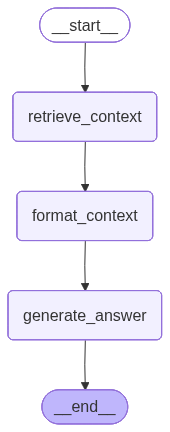

In [13]:
# Visualize the RAG workflow graph
display(Image(rag_app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))


## Step 12 - Test the RAG Agent

Now let's test our RAG agent with some example questions about the Tesla vehicle manual. This demonstrates how the complete system works:

1. **User asks a question** → flows through the graph
2. **Retrieval node** finds relevant information from the manual
3. **Format node** structures the context
4. **Generation node** creates a comprehensive answer
5. **Result** is a helpful, accurate answer based on the manual


In [14]:
# Helper function to ask a question and get an answer
def ask_question(question: str) -> str:
    """
    Ask a question to the RAG agent and get an answer.
    
    Args:
        question: The user's question about the Tesla manual
        
    Returns:
        The answer generated by the agent
    """
    # Create initial state with the user's question
    initial_state: RAGState = {
        "question": question,
        "relevant_chunks": None,  # Will be filled by retrieve_context
        "context": None,  # Will be filled by format_context
        "answer": None  # Will be filled by generate_answer
    }
    
    # Execute the complete RAG pipeline
    result = rag_app.invoke(initial_state)
    
    # Return the final answer
    return result["answer"]

# Example questions to test the agent
questions = [
    "How do I adjust the mirrors in my Tesla?",
    "What should I do if my Tesla battery runs out?",
    "How do I use Autopilot?"
]

# Test the agent with each question
for i, question in enumerate(questions, 1):
    print(f"\n{'='*70}")
    print(f"Question {i}: {question}")
    print(f"{'='*70}")
    
    # Get the answer
    answer = ask_question(question)
    
    # Display the answer
    print(f"\nAnswer:\n{answer}")
    print(f"\n{'-'*70}")



Question 1: How do I adjust the mirrors in my Tesla?

[retrieve_context] Retrieved 3 relevant chunks
[retrieve_context] Similarity scores: [0.64560306 0.63355315 0.614888  ]

[format_context] Formatted 3 chunks into context

[generate_answer] Generated answer (2436 characters)

Answer:
Based on the provided Model 3 manual excerpt, here’s how to adjust and manage your mirrors:

Adjust exterior mirror position
- Use the left scroll button on the steering wheel:
  - Roll up/down to move the mirror up/down.
  - Press left/right to move the mirror inward/outward.
- Note: The steering wheel design may vary, but the function is the same.

Set and use Mirror Auto Tilt (tilt in Reverse)
- Enable Mirror Auto Tilt: Controls > Mirrors > Mirror Auto Tilt.
- With Mirror Auto Tilt enabled, adjust the mirrors to the desired tilted position (while setting up the Reverse tilt), then touch Save.
- When you shift into Reverse, the mirrors tilt to your saved position; when you shift out of Reverse, they r


**What just happened?**
Our RAG system successfully processed the question by:
- Generating a semantic embedding for the question
- Finding the most similar content in the manual
- Synthesizing a helpful answer using the retrieved context

This demonstrates the power of combining vector search (finding relevant info) with LLM reasoning (generating natural responses).

And that's it! Congratulations! You've successfully built a first complete RAG application using LangGraph. Here's what we accomplished:

### What We Built

1. ✅ **Data Ingestion Pipeline**: Extracted, chunked, embedded, and stored the Tesla manual in a vector database
2. ✅ **RAG Agent**: Built a LangGraph workflow that retrieves relevant information and generates accurate answers
3. ✅ **Semantic Search**: Implemented vector similarity search for finding relevant content
4. ✅ **LLM Integration**: Combined retrieval with generation for intelligent question-answering

### Key Concepts Learned

- **RAG (Retrieval-Augmented Generation)**: Combining external knowledge retrieval with LLM generation
- **Vector Databases**: Storing and searching text using semantic embeddings
- **LangGraph Orchestration**: Managing multi-step AI workflows with state management
- **Document Processing**: Extracting and chunking text from PDFs for AI applications

### How to Extend This Application

This RAG application provides a solid foundation that you can extend in many ways:

1. **Enhanced Retrieval**:
   - Add re-ranking to improve result quality
   - Implement hybrid search (combining semantic + keyword search)
   - Add metadata filtering (e.g., search only in specific chapters)

2. **Better Chunking**:
   - Experiment with different chunk sizes and overlaps
   - Use semantic chunking to split at natural topic boundaries
   - Add metadata to chunks (page numbers, sections, etc.)

3. **Advanced Agent Features**:
   - Add conversation memory for follow-up questions
   - Implement multi-hop retrieval (refining queries based on initial results)
   - Add citation tracking (show which parts of the manual were used)

4. **Production Improvements**:
   - Add error handling and retry logic
   - Implement caching for frequently asked questions
   - Add monitoring and logging
   - Scale to handle multiple users concurrently

5. **Different Use Cases**:
   - Apply to other technical documentation
   - Use for legal document Q&A
   - Build support chatbots for other products
   - Create research assistants for scientific papers

The modular design of our pipeline makes it easy to add these enhancements without disrupting the core functionality. Happy building! 🚀
